# 经典CNN

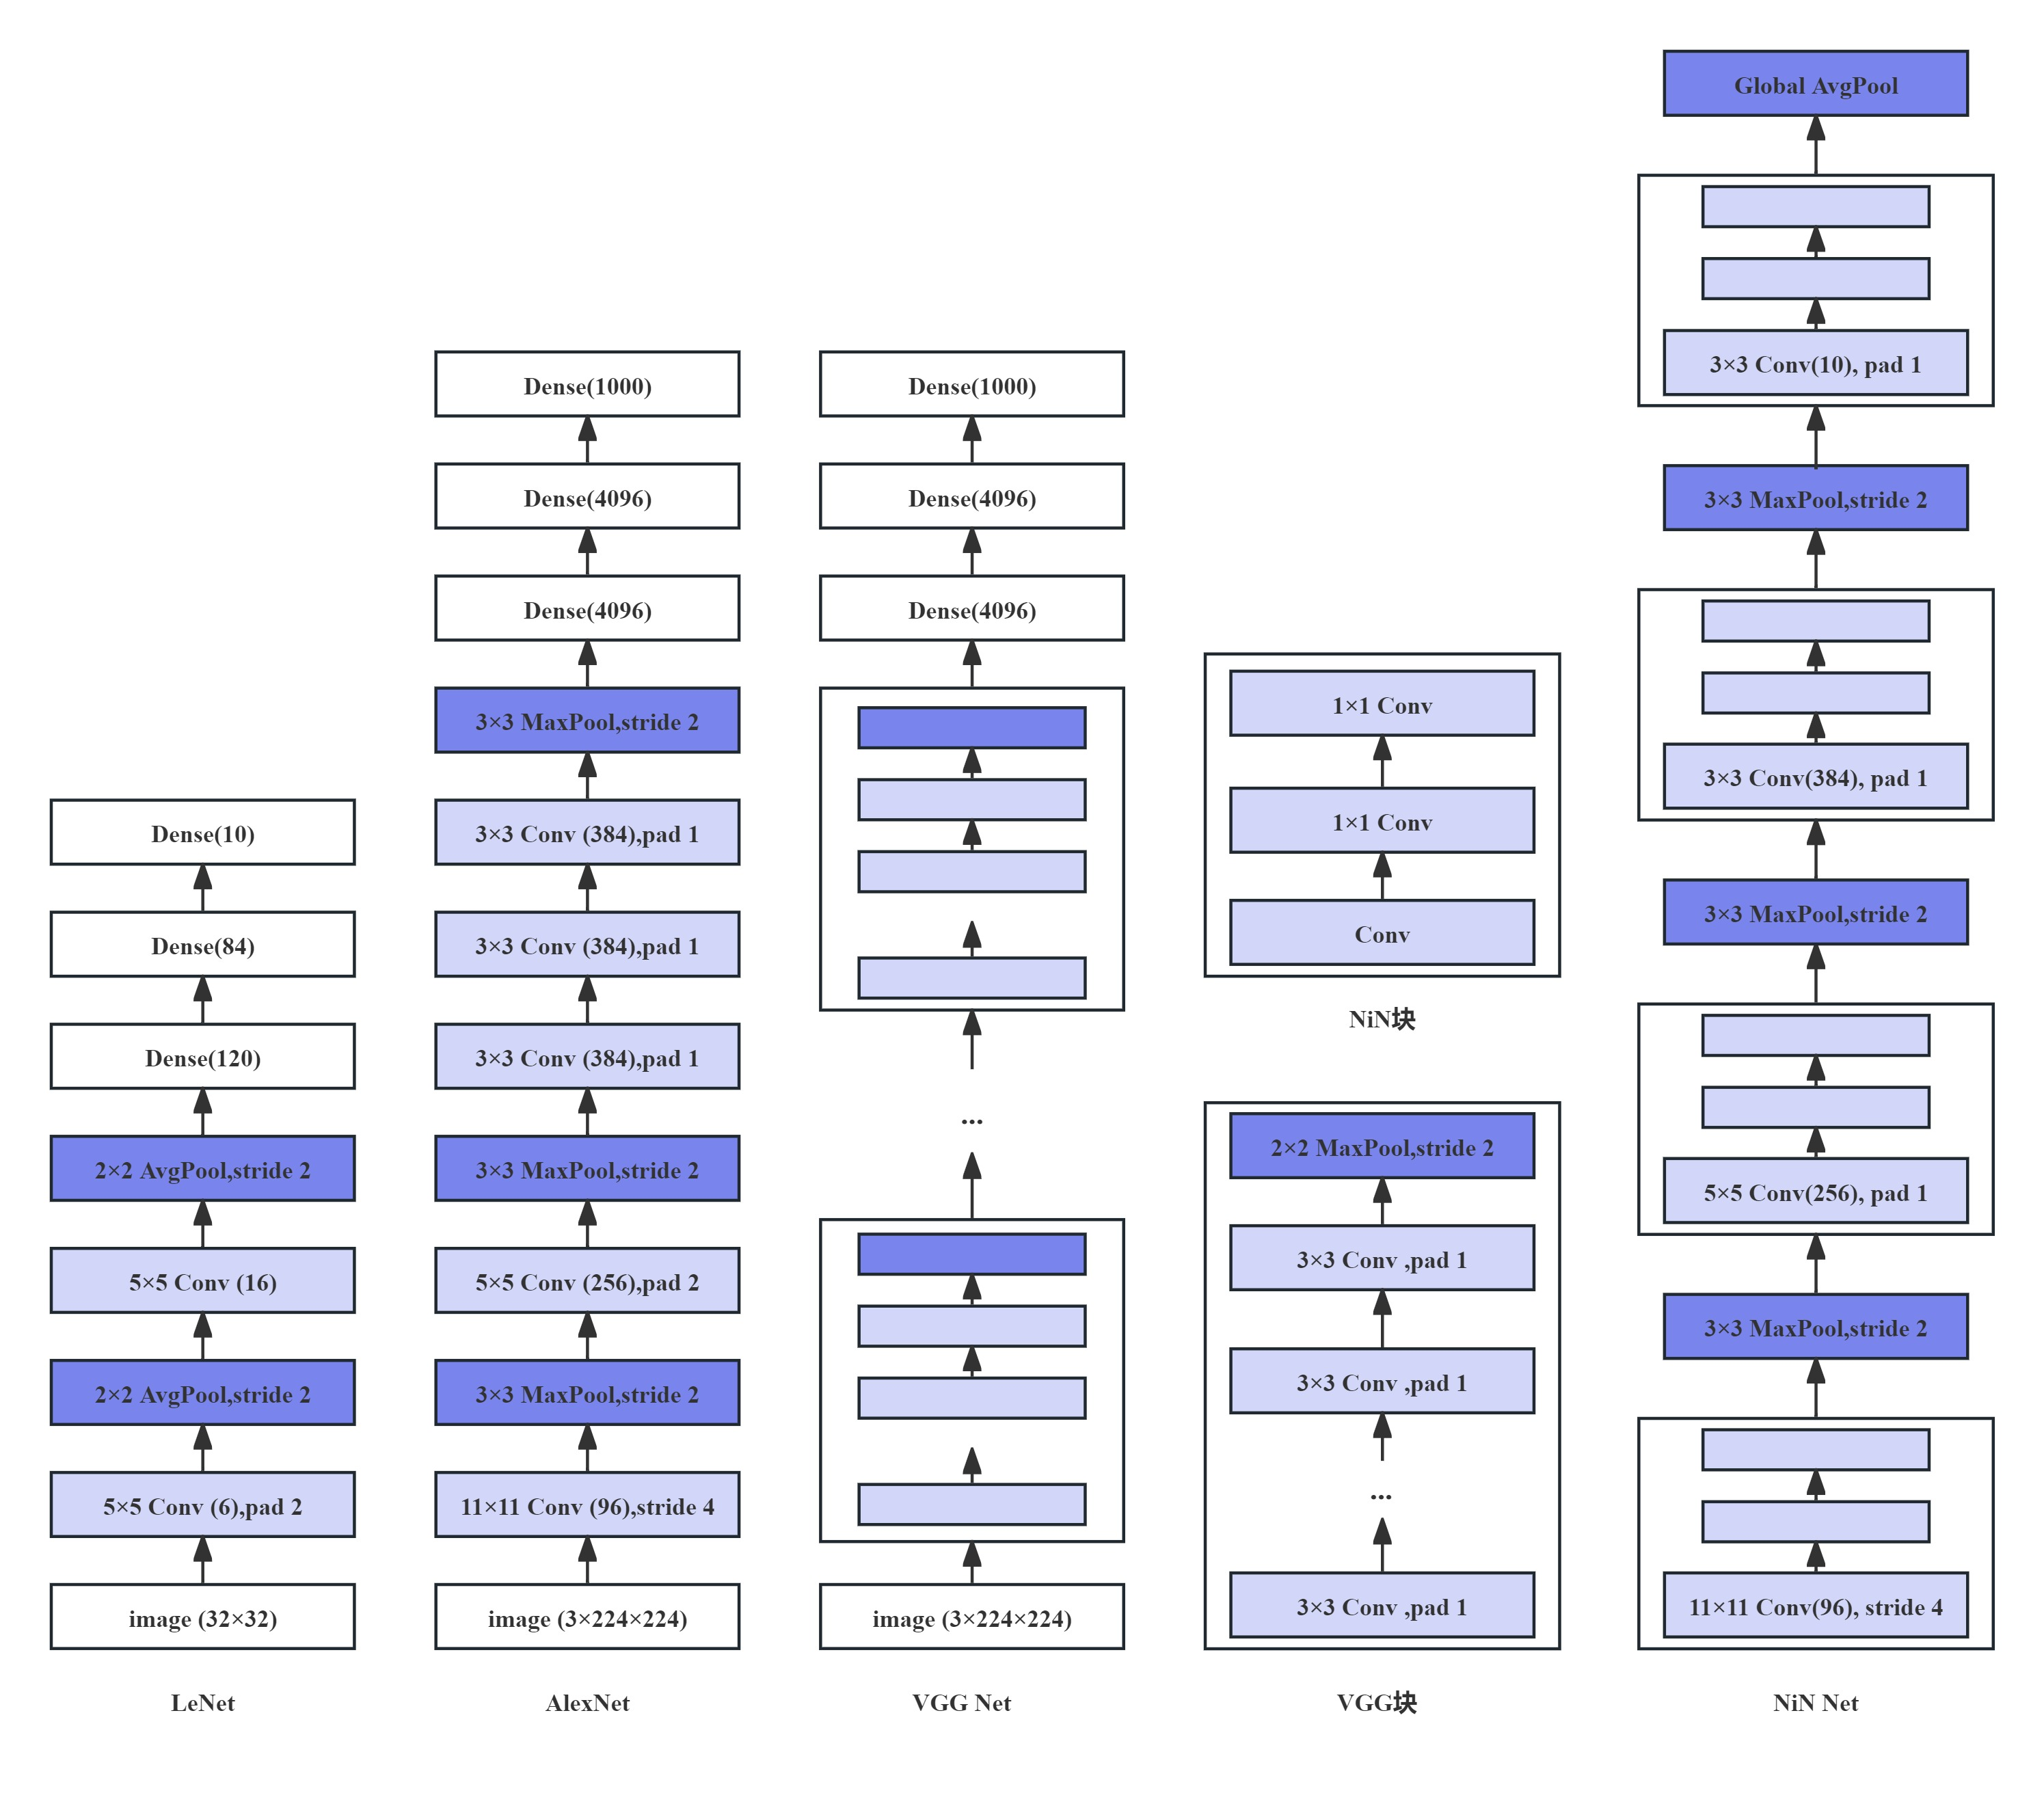

# LeNet

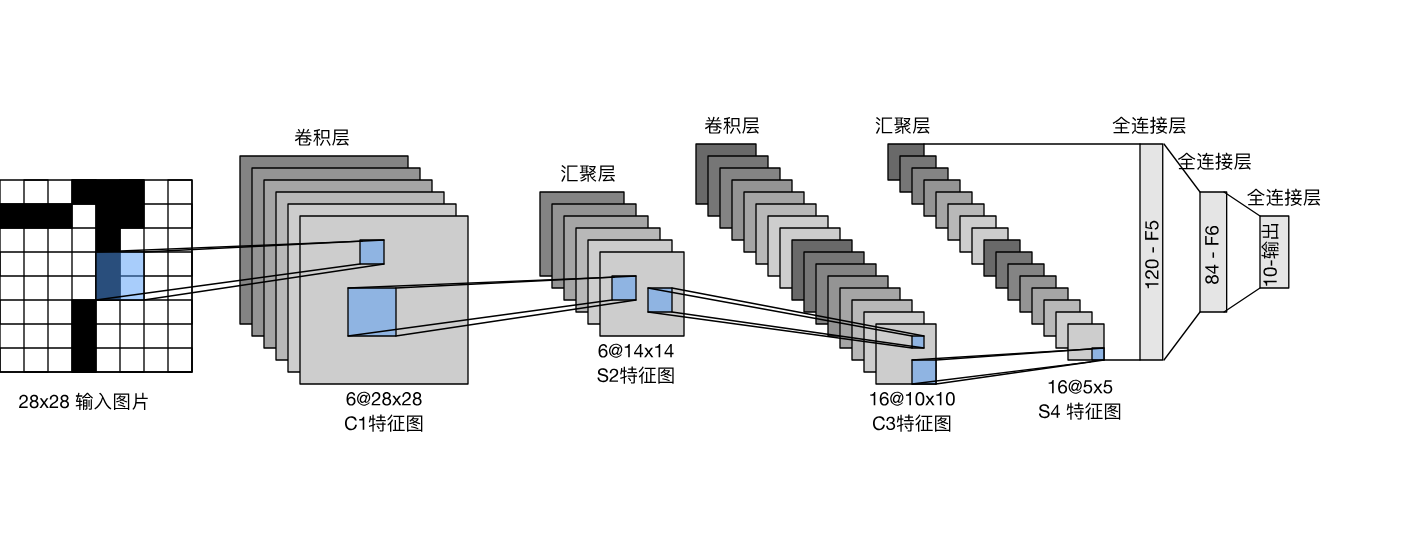

输入层：输入32×32灰度图像

卷积层C1：6个1×5×5的卷积核，步幅为2；输出28×28×6

池化层S2：平均池化，2×2的窗口，步幅为2；输出14×14×6

卷积层C3：16个1×5×5的卷积核；输出10×10×16

池化层S4：平均池化，2×2的窗口，步长为2；输出5×5×16

全连接层：相当于使用120个5×5的卷积核，由于上一层的输出正好是5×5，所以这个卷积操作相当于对每个点进行全连接；输出1×1×120

In [1]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils import data
import time

In [2]:
def get_dataloader_workers():
    """使用4个并行进程读取数据"""
    return 4
    
def load_data_FashionMNIST(batch_size, resize=None):
    """
    下载FashionMNIST数据集，加载到内存
    batch_size: 批量大小
    resize: 可选的图像调整尺寸
    """
    trans = [transforms.ToTensor()] # 将PIL图像转换为Tensor

    # 如果需要调整图像大小
    if resize: 
        trans.insert(0, transforms.Resize(resize)) 
    trans = transforms.Compose(trans) # 组合多个转换操作

    # 下载并加载训练集和测试集
    mnist_train = torchvision.datasets.FashionMNIST(root='D:/Python_study/DL_1/MNIST_Data',
                                                    train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(root='D:/Python_study/DL_1/MNIST_Data',
                                                   train=False, transform=trans, download=True)

    print(f'训练集{len(mnist_train)},测试集{len(mnist_test)}')
    print(f'数据大小{mnist_train[0][0].shape}')  # 28 by 28像素单通道灰度图像

    # 创建数据迭代器，用于批量加载数据
    train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                                 num_workers=get_dataloader_workers())
    test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False,
                                num_workers=get_dataloader_workers())

    return mnist_train, mnist_test, train_iter, test_iter

def accuracy(y_hat, y):
    """计算预测准确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1) # 获取预测的类别
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        '''# 创建包含n个0.0的列表，每个位置对应一个要累加的变量'''
        self.data = [0.0] * n

    def add(self, *args): 
        """
        添加多个值到累加器
        *args是可变位置参数,允许接受任意数量的参数,并存储在名为 args 的元组中
        """
        processed_args = []
        for b in args:
            # isinstance(b, torch.Tensor)检查 b 是否是 torch.Tensor 的实例
            if isinstance(b, torch.Tensor):
                # 张量形式无法直接与 Python 数值运算
                # .detach()从计算图中分离张量,.item()将单元素张量转换为 Python 标量
                processed_args.append(b.detach().item())
            else:
                processed_args.append(b)
                
        # zip()将 elf.data 和 args 对应元素配对     
        self.data = [a + float(b) for a, b in zip(self.data, processed_args)]
        
    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

class Timer:
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        self.tik = time.time()

    def stop(self):
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def sum(self):
        return sum(self.times)

In [3]:
class Reshape(torch.nn.Module):
    def forward(self, x):
        return x.view(-1, 1, 28, 28)

In [4]:
def evaluate_accuracy_gpu(net, data_iter, device=None):
    '''使用GPU计算模型在数据集上的精度'''
    # 判断 net 是否是 torch.nn.Module 的实例，如果是则设置为评估模式
    if isinstance(net, torch.nn.Module):
        net.eval() # 设置模型为评估模式，关闭 dropout 等训练时特有的层
        if not device: # 如果没有指定 device ，则使用模型参数所在的设备
            device = next(iter(net.parameters())).device
    
    # 初始化一个累加器，累加两个值：正确预测的数量和总样本数
    metric = Accumulator(2)
    
    for X, y in data_iter:
        if isinstance(X, list):
            X = [x.to(device) for x in X]
        else:
            X = X.to(device) # 将输入数据移动到指定设备
        y = y.to(device)
        # # 计算当前批次的正确预测数，并累加到metric中
        metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [5]:
def try_gpu():
    """如果有GPU可用则返回GPU设备，否则返回CPU设备。"""
    if torch.cuda.is_available(): # 检查CUDA是否可用
        return torch.device('cuda:0')  # 返回第一个GPU设备,索引为0
    return torch.device('cpu')

In [6]:
def train(net, train_iter, test_iter, num_epoch, lr, device):
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device) # 将模型移动到指定设备
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    timer = Timer()
    
    for epoch in range(num_epoch):
        # 初始化累加器，累加3个值：损失总和，正确预测数，样本数
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)       # 前向传播
            l = loss(y_hat, y)   # 计算损失
            l.backward()         # 反向传播
            optimizer.step()     # 更新模型参数
            metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
        test_acc = evaluate_accuracy_gpu(net, test_iter, device)
        print(f'Epoch {epoch+1}: '
              f'Train Loss {train_l:.4f}, Acc {train_acc:.3f}; '
              f'Test Acc {test_acc:.3f}')
        print(f'{metric[2] * num_epoch / timer.sum():.1f} example/sec'
              f'on {str(device)}')

In [7]:
LeNet = torch.nn.Sequential(
    Reshape(), nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
    nn.Linear(120, 84), nn.ReLU(),
    nn.Linear(84, 10)
)

In [8]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in LeNet:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape: \t', X.shape)

Reshape output shape: 	 torch.Size([1, 1, 28, 28])
Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
ReLU output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
ReLU output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
ReLU output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
ReLU output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [9]:
batch_size, lr, num_epoch = 256, 0.2, 10
*_,train_iter, test_iter = load_data_FashionMNIST(batch_size=batch_size)
train(LeNet, train_iter, test_iter, num_epoch, lr, try_gpu())

训练集60000,测试集10000
数据大小torch.Size([1, 28, 28])
training on cuda:0
Epoch 1: Train Loss 1.4538, Acc 0.467; Test Acc 0.591
536265.8 example/secon cuda:0
Epoch 2: Train Loss 0.6022, Acc 0.769; Test Acc 0.765
281589.3 example/secon cuda:0
Epoch 3: Train Loss 0.4915, Acc 0.814; Test Acc 0.779
191724.5 example/secon cuda:0
Epoch 4: Train Loss 0.4408, Acc 0.836; Test Acc 0.832
147679.7 example/secon cuda:0
Epoch 5: Train Loss 0.4046, Acc 0.850; Test Acc 0.825
119800.2 example/secon cuda:0
Epoch 6: Train Loss 0.3810, Acc 0.857; Test Acc 0.824
100274.3 example/secon cuda:0
Epoch 7: Train Loss 0.3633, Acc 0.865; Test Acc 0.808
86390.6 example/secon cuda:0
Epoch 8: Train Loss 0.3477, Acc 0.870; Test Acc 0.856
76399.9 example/secon cuda:0
Epoch 9: Train Loss 0.3332, Acc 0.875; Test Acc 0.857
67925.0 example/secon cuda:0
Epoch 10: Train Loss 0.3224, Acc 0.879; Test Acc 0.860
60854.7 example/secon cuda:0


# AlexNet

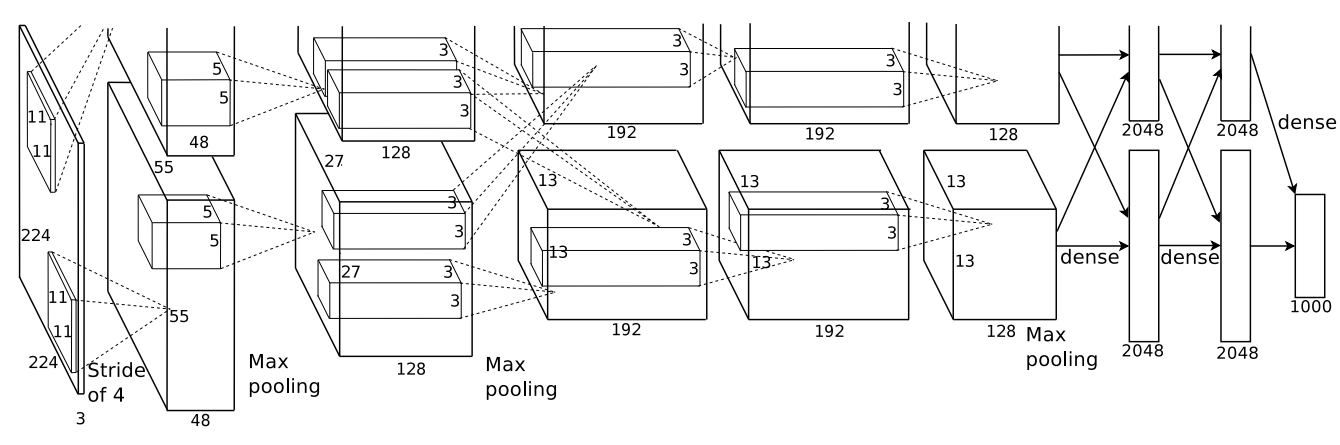

In [10]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils import data
import time

In [11]:
AlexNet = nn.Sequential(
    # 使用 Fashion-MNIST 数据集，输入单通道，输出类别数为 10，而非论文中的 3 通道和 1000 输出
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(), nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(p=0.5),
    nn.Linear(4096, 10))

In [12]:
X = torch.rand(size=(1, 1, 224, 224), dtype=torch.float32)
for layer in AlexNet:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape: \t', X.shape)

Conv2d output shape: 	 torch.Size([1, 96, 54, 54])
ReLU output shape: 	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape: 	 torch.Size([1, 96, 26, 26])
Conv2d output shape: 	 torch.Size([1, 256, 26, 26])
ReLU output shape: 	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape: 	 torch.Size([1, 256, 12, 12])
Conv2d output shape: 	 torch.Size([1, 384, 12, 12])
ReLU output shape: 	 torch.Size([1, 384, 12, 12])
Conv2d output shape: 	 torch.Size([1, 384, 12, 12])
ReLU output shape: 	 torch.Size([1, 384, 12, 12])
Conv2d output shape: 	 torch.Size([1, 256, 12, 12])
ReLU output shape: 	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape: 	 torch.Size([1, 256, 5, 5])
Flatten output shape: 	 torch.Size([1, 6400])
Linear output shape: 	 torch.Size([1, 4096])
ReLU output shape: 	 torch.Size([1, 4096])
Dropout output shape: 	 torch.Size([1, 4096])
Linear output shape: 	 torch.Size([1, 4096])
ReLU output shape: 	 torch.Size([1, 4096])
Dropout output shape: 	 torch.Size([1, 4096])
Linear output sh

In [13]:
batch_size, lr, num_epoch = 128, 0.01, 10
*_,train_iter, test_iter = load_data_FashionMNIST(batch_size=batch_size, resize=224) # resize 配合 AlexNet 的需求
train(AlexNet, train_iter, test_iter, num_epoch, lr, try_gpu())

训练集60000,测试集10000
数据大小torch.Size([1, 224, 224])
training on cuda:0
Epoch 1: Train Loss 1.2678, Acc 0.530; Test Acc 0.731
13457.3 example/secon cuda:0
Epoch 2: Train Loss 0.6405, Acc 0.762; Test Acc 0.800
6685.3 example/secon cuda:0
Epoch 3: Train Loss 0.5310, Acc 0.802; Test Acc 0.827
4434.5 example/secon cuda:0
Epoch 4: Train Loss 0.4662, Acc 0.827; Test Acc 0.808
3315.6 example/secon cuda:0
Epoch 5: Train Loss 0.4261, Acc 0.843; Test Acc 0.852
2648.1 example/secon cuda:0
Epoch 6: Train Loss 0.3959, Acc 0.854; Test Acc 0.867
2206.3 example/secon cuda:0
Epoch 7: Train Loss 0.3755, Acc 0.863; Test Acc 0.869
1890.7 example/secon cuda:0
Epoch 8: Train Loss 0.3535, Acc 0.870; Test Acc 0.872
1653.7 example/secon cuda:0
Epoch 9: Train Loss 0.3399, Acc 0.875; Test Acc 0.879
1470.9 example/secon cuda:0
Epoch 10: Train Loss 0.3285, Acc 0.879; Test Acc 0.884
1324.9 example/secon cuda:0


# VGG

增加卷积层的深度比宽度效果更好，所以使用更多层3×3卷积，而不是层数较少但宽度更大的5×5卷积

VGG块:
n层m通道的3×3Conv2d(padding=1) → 2×2MaxPool2d(stride=2)

VGG架构：
多个VGG块后接全连接层，不同次数的重复块得到不同的架构

VGG-16包含5个VGG块，2+2+3+3+3=13个卷积层，5个最大池化层，13个卷积层+3个全连接层=16层

VGG-19包含5个VGG块，2+2+4+4+4=16个卷积层，5个最大池化层，16个卷积层+3个全连接层=19层

In [14]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils import data
import time

In [15]:
def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(
            in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

In [16]:
def vgg(conv_arch):
    conv_blks = []
    in_channels = 1
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(
            num_convs, in_channels, out_channels))
        in_channels = out_channels

    return nn.Sequential(
        *conv_blks, nn.Flatten(),
        nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(p=0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(p=0.5),
        nn.Linear(4096, 10))

In [17]:
conv_arch = ((1,64), (1,128), (2, 256), (2, 512), (2,512))
VGG = vgg(conv_arch)

In [18]:
X = torch.randn(size=(1, 1, 224, 224), dtype=torch.float32)
for blk in VGG:
    X = blk(X)
    print(blk.__class__.__name__, 'output shape: \t', X.shape)
# 高宽减半，通道数翻倍

Sequential output shape: 	 torch.Size([1, 64, 112, 112])
Sequential output shape: 	 torch.Size([1, 128, 56, 56])
Sequential output shape: 	 torch.Size([1, 256, 28, 28])
Sequential output shape: 	 torch.Size([1, 512, 14, 14])
Sequential output shape: 	 torch.Size([1, 512, 7, 7])
Flatten output shape: 	 torch.Size([1, 25088])
Linear output shape: 	 torch.Size([1, 4096])
ReLU output shape: 	 torch.Size([1, 4096])
Dropout output shape: 	 torch.Size([1, 4096])
Linear output shape: 	 torch.Size([1, 4096])
ReLU output shape: 	 torch.Size([1, 4096])
Dropout output shape: 	 torch.Size([1, 4096])
Linear output shape: 	 torch.Size([1, 10])


In [19]:
# 由于计算量较大，构造一个通道较少的VGG-11
conv_arch = ((1,64), (1,128), (2, 256), (2, 512), (2,512))
ratio = 4
small_conv_arch = [(pair[0], pair[1] // ratio) for pair in conv_arch]
small_VGG11 = vgg(small_conv_arch)

In [20]:
batch_size, lr, num_epoch = 128, 0.01, 10
*_, train_iter, test_iter = load_data_FashionMNIST(batch_size=batch_size, resize=224)
train(small_VGG11, train_iter, test_iter, num_epoch, lr, try_gpu())

训练集60000,测试集10000
数据大小torch.Size([1, 224, 224])
training on cuda:0
Epoch 1: Train Loss 1.7375, Acc 0.356; Test Acc 0.745
10082.5 example/secon cuda:0
Epoch 2: Train Loss 0.6229, Acc 0.770; Test Acc 0.822
4991.2 example/secon cuda:0
Epoch 3: Train Loss 0.4847, Acc 0.822; Test Acc 0.849
3322.2 example/secon cuda:0
Epoch 4: Train Loss 0.4250, Acc 0.845; Test Acc 0.851
2455.9 example/secon cuda:0
Epoch 5: Train Loss 0.3875, Acc 0.859; Test Acc 0.872
1963.2 example/secon cuda:0
Epoch 6: Train Loss 0.3639, Acc 0.868; Test Acc 0.880
1639.8 example/secon cuda:0
Epoch 7: Train Loss 0.3416, Acc 0.876; Test Acc 0.885
1406.1 example/secon cuda:0
Epoch 8: Train Loss 0.3202, Acc 0.885; Test Acc 0.884
1227.6 example/secon cuda:0
Epoch 9: Train Loss 0.3062, Acc 0.889; Test Acc 0.889
1089.7 example/secon cuda:0
Epoch 10: Train Loss 0.2919, Acc 0.895; Test Acc 0.894
980.2 example/secon cuda:0


# NiN

卷积层后的第一个全连接层的参数很多

LeNet 16×5×5×120=48k

AlexNet 256×5×5×4096=26M

VGG 512×7×7×4096=102M

NiN块：Conv2d → 1×1Conv2d → 1×1Conv2d

将1×1Conv2d代替全连接层

交替使用NiN块和MaxPool2d(stride=2)逐步减小高宽和增大通道数

最后使用全局平均池化层得到输出，其输入通道数是类别数

In [21]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils import data
import time

In [22]:
def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),nn.Conv2d(out_channels, out_channels, kernel_size=1), 
        nn.ReLU(),nn.Conv2d(out_channels, out_channels, kernel_size=1), 
        nn.ReLU())

In [23]:
# AlexNet 的卷积层替换为 NiN 块
NiN = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),nn.Dropout(0.5),
    nin_block(384, 10, kernel_size=3, strides=1, padding=1), # 标签类别数是10
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()) # 将四维的输出转成二维的输出，其形状为(批量大小,10)

In [24]:
X = torch.rand(size=(1, 1, 224, 224), dtype=torch.float32)
for layer in NiN:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape: \t', X.shape)

Sequential output shape: 	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape: 	 torch.Size([1, 96, 26, 26])
Sequential output shape: 	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape: 	 torch.Size([1, 256, 12, 12])
Sequential output shape: 	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape: 	 torch.Size([1, 384, 5, 5])
Dropout output shape: 	 torch.Size([1, 384, 5, 5])
Sequential output shape: 	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape: 	 torch.Size([1, 10, 1, 1])
Flatten output shape: 	 torch.Size([1, 10])


In [25]:
batch_size, lr, num_epoch = 128, 0.01, 10
*_, train_iter, test_iter = load_data_FashionMNIST(batch_size=batch_size, resize=224)
train(NiN, train_iter, test_iter, num_epoch, lr, try_gpu())

训练集60000,测试集10000
数据大小torch.Size([1, 224, 224])
training on cuda:0
Epoch 1: Train Loss 2.3122, Acc 0.100; Test Acc 0.100
11519.3 example/secon cuda:0
Epoch 2: Train Loss 2.3055, Acc 0.101; Test Acc 0.100
5783.6 example/secon cuda:0
Epoch 3: Train Loss 2.3021, Acc 0.105; Test Acc 0.152
3853.3 example/secon cuda:0
Epoch 4: Train Loss 2.2943, Acc 0.179; Test Acc 0.219
2886.7 example/secon cuda:0
Epoch 5: Train Loss 2.2720, Acc 0.196; Test Acc 0.193
2312.1 example/secon cuda:0
Epoch 6: Train Loss 2.1118, Acc 0.228; Test Acc 0.380
1936.5 example/secon cuda:0
Epoch 7: Train Loss 1.6676, Acc 0.415; Test Acc 0.512
1665.8 example/secon cuda:0
Epoch 8: Train Loss 1.0475, Acc 0.600; Test Acc 0.687
1457.1 example/secon cuda:0
Epoch 9: Train Loss 0.8592, Acc 0.682; Test Acc 0.726
1296.7 example/secon cuda:0
Epoch 10: Train Loss 0.7622, Acc 0.715; Test Acc 0.724
1168.9 example/secon cuda:0
